# Power Outage Forecasting — Full Pipeline
**Structure:**
1. Shared Setup & Data Loading
2. Feature Engineering
3. **Model A**: XGBoost (direct forecasting, top-20 raw features)
4. **Model B**: Spatio-Temporal AR Neural Network (48h model + fine-tuned 24h)
5. **Model C**: SARIMAX (per-county persistence)
6. 3-Model Ensemble
7. Submission & Policy Recommendation

---
## 1. Shared Setup & Data Loading

In [168]:
!pip install netCDF4 xarray xgboost statsmodels -q
from statsmodels.tsa.statespace.sarimax import SARIMAX
print("SARIMAX imported successfully")

SARIMAX imported successfully


In [169]:
# If using Google Drive, uncomment:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [170]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import os, time, warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DATA_DIR = "/content/drive/MyDrive/MLPS_Final_Project/dataset/data/"
RESULTS_DIR = "/content/drive/MyDrive/MLPS_Final_Project/dataset/results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


In [171]:
# Load data
ds_train = xr.open_dataset(f"{DATA_DIR}train.nc")
ds_test_24h = xr.open_dataset(f"{DATA_DIR}test_24h_demo.nc")
ds_test_48h = xr.open_dataset(f"{DATA_DIR}test_48h_demo.nc")

timestamps = pd.to_datetime(ds_train.timestamp.values)
locations = list(ds_train.location.values)
features = list(ds_train.feature.values)

outage = ds_train.out.transpose("timestamp", "location").values.astype(float)
weather = ds_train.weather.transpose("timestamp", "location", "feature").values.astype(float)
tracked = ds_train.tracked.transpose("timestamp", "location").values.astype(float)

T, L = outage.shape
F = len(features)
print(f"T={T}, L={L}, F={F}")
print(f"Period: {timestamps.min()} to {timestamps.max()}")

test_24h_ts = pd.to_datetime(ds_test_24h.timestamp.values)
test_48h_ts = pd.to_datetime(ds_test_48h.timestamp.values)
test_24h_truth = ds_test_24h.out.transpose("timestamp", "location").values.astype(float)
test_48h_truth = ds_test_48h.out.transpose("timestamp", "location").values.astype(float)

T=2161, L=83, F=109
Period: 2023-04-01 00:00:00 to 2023-06-30 00:00:00


In [172]:
# Train / validation split — match demo: last 20%
VALIDATION_SPLIT = 0.2
split_idx = int(T * (1 - VALIDATION_SPLIT))

outage_train = outage[:split_idx]
outage_val = outage[split_idx:]
weather_train = weather[:split_idx]
weather_val = weather[split_idx:]
ts_train = timestamps[:split_idx]
ts_val = timestamps[split_idx:]

val_24h_truth = outage_val[:24]
val_48h_truth = outage_val[:48]
val_24h_ts = ts_val[:24]
val_48h_ts = ts_val[:48]

print(f"Train: {outage_train.shape[0]}h ({ts_train.min()} to {ts_train.max()})")
print(f"Val:   {outage_val.shape[0]}h ({ts_val.min()} to {ts_val.max()})")

Train: 1728h (2023-04-01 00:00:00 to 2023-06-11 23:00:00)
Val:   433h (2023-06-12 00:00:00 to 2023-06-30 00:00:00)


---
## 2. Feature Engineering (shared)

In [173]:
# Identify top-20 weather features by correlation with outages (Strictly Training Data)
out_flat = outage_train.reshape(-1)
w_flat = weather_train.reshape(-1, F)
correlations = np.array([np.corrcoef(w_flat[:, i], out_flat)[0, 1] for i in range(F)])
corr_rank = np.argsort(np.abs(correlations))[::-1]

TOP_K = 20
top_feat_idx = corr_rank[:TOP_K]
top_feat_names = [features[i] for i in top_feat_idx]
print(f"Top {TOP_K} features: {top_feat_names}")

TOP_ROLL = 5
roll_feat_idx = corr_rank[:TOP_ROLL]
roll_feat_names = [features[i] for i in roll_feat_idx]

Top 20 features: ['tp', 'tcolw', 'aod', 'unknown_7', 'tcoli', 'unknown_9', 'ssrun', 'siconc', 'sdwe_1', 'cfnsf', 'prate', 'cfrzr', 'cicep', 'ltng', 'hail_2', 'crain', 'bgrun', 'csnow', 'sde', 'sdwe']


In [174]:
# County-level static features (Strictly Training Data)
mean_tracked = np.nanmean(tracked[:split_idx], axis=0)
print(f"Tracked range: {mean_tracked.min():.0f} to {mean_tracked.max():.0f}")

Tracked range: 2016 to 922425


In [175]:
# RMSE evaluation function
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred))**2)))

def evaluate_per_county(truth, pred_df, locations):
    rmses = []
    for i, loc in enumerate(locations):
        loc_str = str(loc)
        loc_pred = pred_df[pred_df['location'].astype(str) == loc_str]['pred'].values
        if len(loc_pred) == truth.shape[0]:
            rmses.append(rmse(truth[:, i], loc_pred))
        else:
            rmses.append(np.nan)
    return rmses

print("Shared setup complete.")

Shared setup complete.


---
---
# MODEL A: XGBoost (Direct Multi-Horizon Forecasting)
Uses top-20 raw weather features + outage lags + rolling stats + temporal features.
One model per horizon step (h=1,...,H).

In [176]:
# =====================================================
# XGBoost: Build feature matrix
# =====================================================

N_LAGS = 24
ROLL_WINDOWS = [6, 12, 24]

def build_xgb_features(outage_arr, weather_arr, timestamps_arr, mean_tracked,
                       top_feat_idx, roll_feat_idx, roll_windows, n_lags):
    T_arr, L_arr = outage_arr.shape
    ts_pd = pd.to_datetime(timestamps_arr)
    hour = ts_pd.hour.values
    dow = ts_pd.dayofweek.values
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    dow_sin = np.sin(2 * np.pi * dow / 7)
    dow_cos = np.cos(2 * np.pi * dow / 7)

    roll_feats_all = {}
    for li in range(L_arr):
        roll_list = []
        for fi in roll_feat_idx:
            series = pd.Series(weather_arr[:, li, fi])
            for w in roll_windows:
                roll_list.append(series.rolling(w, min_periods=1).mean().values)
        roll_feats_all[li] = np.column_stack(roll_list)

    start = n_lags
    feature_dict = {}
    for li in range(L_arr):
        rows = []
        for t in range(start, T_arr):
            feat = []
            for lag in range(1, n_lags + 1):
                feat.append(outage_arr[t - lag, li])
            for fi in top_feat_idx:
                feat.append(weather_arr[t, li, fi])
            feat.extend(roll_feats_all[li][t])
            feat.extend([hour_sin[t], hour_cos[t], dow_sin[t], dow_cos[t]])
            feat.append(np.log1p(mean_tracked[li]))
            rows.append(feat)
        feature_dict[li] = np.array(rows, dtype=np.float32)

    return feature_dict, start

print("Building XGBoost feature matrix (training)...")
xgb_feat_train, xgb_start = build_xgb_features(
    outage_train, weather_train, ts_train, mean_tracked,
    top_feat_idx, roll_feat_idx, ROLL_WINDOWS, N_LAGS
)
D_xgb = xgb_feat_train[0].shape[1]
print(f"Feature dim: {D_xgb}, Valid timesteps per county: {xgb_feat_train[0].shape[0]}")

Building XGBoost feature matrix (training)...
Feature dim: 64, Valid timesteps per county: 1704


In [177]:
# =====================================================
# XGBoost: Build training data for a given horizon h
# =====================================================

def build_xgb_train_data(feature_dict, outage_arr, start_idx, horizon):
    X_list, y_list = [], []
    T_arr = outage_arr.shape[0]
    for li, feats in feature_dict.items():
        T_valid = feats.shape[0]
        for idx in range(T_valid):
            t = start_idx + idx
            target_t = t + horizon
            if target_t < T_arr:
                X_list.append(feats[idx])
                y_list.append(outage_arr[target_t, li])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

In [178]:
# =====================================================
# XGBoost: Train one model per horizon step
# =====================================================

XGB_PARAMS = {
    'objective': 'reg:squarederror',
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 10,
    'n_estimators': 300,
    'random_state': RANDOM_SEED,
    'tree_method': 'hist',
    'verbosity': 0
}

def train_xgb_models(feature_dict, outage_arr, start_idx, max_horizon, params):
    models = {}
    for h in tqdm(range(1, max_horizon + 1), desc="Training XGBoost models"):
        X, y = build_xgb_train_data(feature_dict, outage_arr, start_idx, h)
        model = xgb.XGBRegressor(**params)
        model.fit(X, y)
        models[h] = model
    return models

print("Training XGBoost for 24h horizon...")
xgb_models_24h = train_xgb_models(xgb_feat_train, outage_train, xgb_start, 24, XGB_PARAMS)

print("\nTraining XGBoost for 48h horizon...")
xgb_models_48h = train_xgb_models(xgb_feat_train, outage_train, xgb_start, 48, XGB_PARAMS)

Training XGBoost for 24h horizon...


Training XGBoost models:   0%|          | 0/24 [00:00<?, ?it/s]


Training XGBoost for 48h horizon...


Training XGBoost models:   0%|          | 0/48 [00:00<?, ?it/s]

In [179]:
# =====================================================
# XGBoost: Prediction function
# =====================================================

def predict_xgb(models, outage_full, weather_full, timestamps_full,
                mean_tracked, top_feat_idx, roll_feat_idx, roll_windows, n_lags,
                pred_timestamps, locations, horizon):
    T_full, L_full = outage_full.shape
    feat_dict_last, _ = build_xgb_features(
        outage_full, weather_full, timestamps_full, mean_tracked,
        top_feat_idx, roll_feat_idx, roll_windows, n_lags
    )
    rows = []
    for h in range(1, horizon + 1):
        model = models[h]
        for li in range(L_full):
            feat = feat_dict_last[li][-1:]
            pred = model.predict(feat)[0]
            pred = max(pred, 0)
            rows.append({
                'timestamp': pred_timestamps[h - 1],
                'location': str(locations[li]),
                'pred': pred
            })
    df = pd.DataFrame(rows)
    df = df.sort_values(['timestamp', 'location']).reset_index(drop=True)
    return df

In [180]:
# =====================================================
# XGBoost: Validate
# =====================================================

print("Generating XGBoost validation predictions...")
xgb_val_24h_df = predict_xgb(
    xgb_models_24h, outage_train, weather_train, ts_train,
    mean_tracked, top_feat_idx, roll_feat_idx, ROLL_WINDOWS, N_LAGS,
    val_24h_ts, locations, 24
)
xgb_val_48h_df = predict_xgb(
    xgb_models_48h, outage_train, weather_train, ts_train,
    mean_tracked, top_feat_idx, roll_feat_idx, ROLL_WINDOWS, N_LAGS,
    val_48h_ts, locations, 48
)

xgb_val_24h_rmses = evaluate_per_county(val_24h_truth, xgb_val_24h_df, locations)
xgb_val_48h_rmses = evaluate_per_county(val_48h_truth, xgb_val_48h_df, locations)

print(f"\nXGBoost Validation RMSE:")
print(f"  24h: {np.nanmean(xgb_val_24h_rmses):.4f}")
print(f"  48h: {np.nanmean(xgb_val_48h_rmses):.4f}")

Generating XGBoost validation predictions...

XGBoost Validation RMSE:
  24h: 96.6404
  48h: 78.0673


In [181]:
# =====================================================
# XGBoost: Retrain on full data & generate test predictions
# =====================================================

print("Rebuilding features on FULL training data...")
xgb_feat_full, xgb_start_full = build_xgb_features(
    outage, weather, timestamps, mean_tracked,
    top_feat_idx, roll_feat_idx, ROLL_WINDOWS, N_LAGS
)

print("Retraining XGBoost on full data (24h)...")
xgb_final_24h = train_xgb_models(xgb_feat_full, outage, xgb_start_full, 24, XGB_PARAMS)

print("Retraining XGBoost on full data (48h)...")
xgb_final_48h = train_xgb_models(xgb_feat_full, outage, xgb_start_full, 48, XGB_PARAMS)

print("\nGenerating test predictions...")
xgb_test_24h_df = predict_xgb(
    xgb_final_24h, outage, weather, timestamps,
    mean_tracked, top_feat_idx, roll_feat_idx, ROLL_WINDOWS, N_LAGS,
    test_24h_ts, locations, 24
)
xgb_test_48h_df = predict_xgb(
    xgb_final_48h, outage, weather, timestamps,
    mean_tracked, top_feat_idx, roll_feat_idx, ROLL_WINDOWS, N_LAGS,
    test_48h_ts, locations, 48
)

xgb_test_24h_df.to_csv(f"{RESULTS_DIR}xgb_pred_24h.csv", index=False)
xgb_test_48h_df.to_csv(f"{RESULTS_DIR}xgb_pred_48h.csv", index=False)
print(f"XGBoost saved: 24h={xgb_test_24h_df.shape}, 48h={xgb_test_48h_df.shape}")

Rebuilding features on FULL training data...
Retraining XGBoost on full data (24h)...


Training XGBoost models:   0%|          | 0/24 [00:00<?, ?it/s]

Retraining XGBoost on full data (48h)...


Training XGBoost models:   0%|          | 0/48 [00:00<?, ?it/s]


Generating test predictions...
XGBoost saved: 24h=(1992, 3), 48h=(3984, 3)


---
---
# MODEL B: Spatio-Temporal AR Neural Network
**Single 48h model** — 24h predictions are sliced from the first 24 outputs.

Components: Temporal Conv (own history) + Spatial Attention (neighbors) + Weather Conv (PCA) + Fusion MLP

In [182]:
# =====================================================
# STAR: Config
# =====================================================

N_PCA = 20  # reduced from 35 — captures ~90% variance, less overfitting
LOOKBACK = 48
STAR_HORIZON = 48  # base model predicts 48h; fine-tuned copy for 24h
K_NEIGHBORS = 5
BATCH_SIZE_STAR = 256
EPOCHS_STAR = 100
LR_STAR = 1e-3
PATIENCE_STAR = 6

print(f"STAR Config: PCA={N_PCA}, lookback={LOOKBACK}, horizon={STAR_HORIZON}, "
      f"K_neighbors={K_NEIGHBORS}, epochs={EPOCHS_STAR}")


STAR Config: PCA=20, lookback=48, horizon=48, K_neighbors=5, epochs=100


In [183]:
# =====================================================
# STAR: Spatial structure — find neighbor counties
# =====================================================

county_corr = np.corrcoef(outage_train.T)  # (L, L)
np.fill_diagonal(county_corr, 0)

neighbor_idx = np.zeros((L, K_NEIGHBORS), dtype=int)
neighbor_corr = np.zeros((L, K_NEIGHBORS))

for i in range(L):
    top_k = np.argsort(county_corr[i])[::-1][:K_NEIGHBORS]
    neighbor_idx[i] = top_k
    neighbor_corr[i] = county_corr[i, top_k]

print(f"Neighbor structure: {K_NEIGHBORS} neighbors per county")
print(f"Mean neighbor corr: {neighbor_corr.mean():.3f}")

Neighbor structure: 5 neighbors per county
Mean neighbor corr: 0.270


In [184]:
# =====================================================
# STAR: PCA on weather + outage normalization
# =====================================================

w_scaler = StandardScaler()
w_train_scaled = w_scaler.fit_transform(weather_train.reshape(-1, F))
pca = PCA(n_components=N_PCA, random_state=RANDOM_SEED)
pca.fit(w_train_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.4f}")

def apply_pca(weather_arr):
    T_w, L_w, F_w = weather_arr.shape
    flat = w_scaler.transform(weather_arr.reshape(-1, F_w))
    return pca.transform(flat).reshape(T_w, L_w, -1)

weather_train_pca = apply_pca(weather_train)
weather_full_pca = apply_pca(weather)

out_mu = np.nanmean(outage_train)
out_sd = max(np.nanstd(outage_train), 1.0)
outage_train_z = (outage_train - out_mu) / out_sd
outage_full_z = (outage - out_mu) / out_sd

print(f"Outage norm: mu={out_mu:.2f}, sd={out_sd:.2f}")

PCA explained variance: 0.7993
Outage norm: mu=34.56, sd=272.78


In [185]:
# =====================================================
# STAR: Build spatio-temporal windows
# =====================================================

def build_spatiotemporal_windows(outage_z, weather_pca, timestamps_arr,
                                  neighbor_idx, lookback, horizon):
    T_w, L_w = outage_z.shape
    K = neighbor_idx.shape[1]
    ts_pd = pd.to_datetime(timestamps_arr)
    hour = ts_pd.hour.values
    dow = ts_pd.dayofweek.values
    mean_tracked_normed = np.log1p(mean_tracked)

    X_own, X_neigh, X_weather, X_static, Y = [], [], [], [], []

    for li in range(L_w):
        neighbors = neighbor_idx[li]
        for t in range(lookback, T_w - horizon + 1):
            X_own.append(outage_z[t - lookback:t, li])
            X_neigh.append(outage_z[t - lookback:t, neighbors].T)
            X_weather.append(weather_pca[t - lookback:t, li, :])
            h = hour[t - 1]
            d = dow[t - 1]
            X_static.append(np.array([
                np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24),
                np.sin(2*np.pi*d/7), np.cos(2*np.pi*d/7),
                mean_tracked_normed[li]
            ], dtype=np.float32))
            Y.append(outage_z[t:t + horizon, li])

    return (np.array(X_own, dtype=np.float32),
            np.array(X_neigh, dtype=np.float32),
            np.array(X_weather, dtype=np.float32),
            np.array(X_static, dtype=np.float32),
            np.array(Y, dtype=np.float32))

In [186]:
# =====================================================
# STAR: Model architecture
# =====================================================

class TemporalConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size - 1)
        self.bn = nn.BatchNorm1d(out_ch)
        self.act = nn.ReLU()
    def forward(self, x):
        out = self.conv(x)[:, :, :-self.conv.padding[0]]
        return self.act(self.bn(out))

class SpatialAttention(nn.Module):
    def __init__(self, temporal_dim, hidden_dim):
        super().__init__()
        self.query = nn.Linear(temporal_dim, hidden_dim)
        self.key = nn.Linear(temporal_dim, hidden_dim)
        self.value = nn.Linear(temporal_dim, hidden_dim)
        self.scale = hidden_dim ** 0.5
    def forward(self, own_enc, neigh_enc):
        q = self.query(own_enc).unsqueeze(1)
        k = self.key(neigh_enc)
        v = self.value(neigh_enc)
        attn = torch.bmm(q, k.transpose(1, 2)) / self.scale
        attn = torch.softmax(attn, dim=-1)
        return torch.bmm(attn, v).squeeze(1)

class SpatioTemporalAR(nn.Module):
    def __init__(self, lookback, n_pca, k_neighbors, horizon,
                 temporal_hidden=64, spatial_hidden=32,
                 weather_hidden=32, fusion_hidden=128, dropout=0.2):
        super().__init__()
        self.own_temporal = nn.Sequential(
            TemporalConvBlock(1, 32, 3), TemporalConvBlock(32, temporal_hidden, 3),
            nn.AdaptiveAvgPool1d(1))
        self.neigh_temporal = nn.Sequential(
            TemporalConvBlock(1, 32, 3), TemporalConvBlock(32, temporal_hidden, 3),
            nn.AdaptiveAvgPool1d(1))
        self.spatial_attn = SpatialAttention(temporal_hidden, spatial_hidden)
        self.weather_enc = nn.Sequential(
            TemporalConvBlock(n_pca, 32, 3), TemporalConvBlock(32, weather_hidden, 3),
            nn.AdaptiveAvgPool1d(1))
        fusion_input = temporal_hidden + spatial_hidden + weather_hidden + 5
        self.fusion = nn.Sequential(
            nn.Linear(fusion_input, fusion_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_hidden, fusion_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_hidden, horizon))

    def forward(self, x_own, x_neigh, x_weather, x_static):
        batch = x_own.size(0)
        own_enc = self.own_temporal(x_own.unsqueeze(1)).squeeze(-1)
        K = x_neigh.size(1)
        neigh_flat = x_neigh.reshape(batch * K, 1, -1)
        neigh_enc = self.neigh_temporal(neigh_flat).squeeze(-1).reshape(batch, K, -1)
        spatial = self.spatial_attn(own_enc, neigh_enc)
        w_enc = self.weather_enc(x_weather.permute(0, 2, 1)).squeeze(-1)
        fused = torch.cat([own_enc, spatial, w_enc, x_static], dim=-1)
        return self.fusion(fused)

n_params = sum(p.numel() for p in SpatioTemporalAR(LOOKBACK, N_PCA, K_NEIGHBORS, STAR_HORIZON).parameters())
print(f"STAR model parameters: {n_params:,}")

STAR model parameters: 64,336


In [187]:
# =====================================================
# STAR: Training function with early stopping
# =====================================================

def train_star_model(X_own_tr, X_neigh_tr, X_w_tr, X_s_tr, Y_tr,
                     X_own_val, X_neigh_val, X_w_val, X_s_val, Y_val,
                     horizon, epochs=EPOCHS_STAR, batch_size=BATCH_SIZE_STAR,
                     lr=LR_STAR, patience=PATIENCE_STAR):

    train_ds = TensorDataset(torch.tensor(X_own_tr), torch.tensor(X_neigh_tr),
                             torch.tensor(X_w_tr), torch.tensor(X_s_tr), torch.tensor(Y_tr))
    val_ds = TensorDataset(torch.tensor(X_own_val), torch.tensor(X_neigh_val),
                           torch.tensor(X_w_val), torch.tensor(X_s_val), torch.tensor(Y_val))
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = SpatioTemporalAR(LOOKBACK, N_PCA, K_NEIGHBORS, horizon,
                             temporal_hidden=64, spatial_hidden=32,
                             weather_hidden=32, fusion_hidden=128, dropout=0.2).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_state = None
    no_improve = 0
    history = {'train': [], 'val': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for own, neigh, w, s, y in train_dl:
            own, neigh, w, s, y = own.to(DEVICE), neigh.to(DEVICE), w.to(DEVICE), s.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            pred = model(own, neigh, w, s)
            loss = criterion(pred, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            train_loss += loss.item() * own.size(0)
        train_loss /= len(train_ds)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for own, neigh, w, s, y in val_dl:
                own, neigh, w, s, y = own.to(DEVICE), neigh.to(DEVICE), w.to(DEVICE), s.to(DEVICE), y.to(DEVICE)
                val_loss += criterion(model(own, neigh, w, s), y).item() * own.size(0)
        val_loss /= len(val_ds)

        scheduler.step(val_loss)
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        cur_lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1:>3}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {cur_lr:.6f}", end="")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(" *")
        else:
            no_improve += 1
            print()
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history

In [188]:
# =====================================================
# STAR: Fine-tune function (reuses pretrained weights)
# =====================================================

def finetune_star_model(pretrained_model, X_own_tr, X_neigh_tr, X_w_tr, X_s_tr, Y_tr,
                        X_own_val, X_neigh_val, X_w_val, X_s_val, Y_val,
                        new_horizon, finetune_epochs=5, lr=1e-4, patience=PATIENCE_STAR):
    """
    Create a new model with different horizon, copy shared weights from
    pretrained 48h model, replace the fusion head, and fine-tune briefly.
    """
    import copy
    new_model = SpatioTemporalAR(LOOKBACK, N_PCA, K_NEIGHBORS, new_horizon,
                                 temporal_hidden=64, spatial_hidden=32,
                                 weather_hidden=32, fusion_hidden=128, dropout=0.2).to(DEVICE)

    # Copy encoder weights (temporal, neighbor, spatial attention, weather)
    pretrained_dict = pretrained_model.state_dict()
    new_dict = new_model.state_dict()
    # Copy everything except the final linear layer in fusion (different output size)
    for k in pretrained_dict:
        if k in new_dict and pretrained_dict[k].shape == new_dict[k].shape:
            new_dict[k] = pretrained_dict[k].clone()
    new_model.load_state_dict(new_dict)

    # Fine-tune with low LR
    train_ds = TensorDataset(torch.tensor(X_own_tr), torch.tensor(X_neigh_tr),
                             torch.tensor(X_w_tr), torch.tensor(X_s_tr), torch.tensor(Y_tr))
    val_ds = TensorDataset(torch.tensor(X_own_val), torch.tensor(X_neigh_val),
                           torch.tensor(X_w_val), torch.tensor(X_s_val), torch.tensor(Y_val))
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE_STAR, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE_STAR, shuffle=False)

    optimizer = torch.optim.Adam(new_model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val_loss = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(finetune_epochs):
        new_model.train()
        train_loss = 0
        for own, neigh, w, s, y in train_dl:
            own, neigh, w, s, y = own.to(DEVICE), neigh.to(DEVICE), w.to(DEVICE), s.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(new_model(own, neigh, w, s), y)
            loss.backward()
            nn.utils.clip_grad_norm_(new_model.parameters(), 5.0)
            optimizer.step()
            train_loss += loss.item() * own.size(0)
        train_loss /= len(train_ds)

        new_model.eval()
        val_loss = 0
        with torch.no_grad():
            for own, neigh, w, s, y in val_dl:
                own, neigh, w, s, y = own.to(DEVICE), neigh.to(DEVICE), w.to(DEVICE), s.to(DEVICE), y.to(DEVICE)
                val_loss += criterion(new_model(own, neigh, w, s), y).item() * own.size(0)
        val_loss /= len(val_ds)

        print(f"  FT Epoch {epoch+1}/{finetune_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}", end='')
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in new_model.state_dict().items()}
            no_improve = 0
            print(' *')
        else:
            no_improve += 1
            print()
            if no_improve >= patience:
                print(f"  Early stopping at FT epoch {epoch+1}")
                break

    new_model.load_state_dict(best_state)
    return new_model

print("Fine-tune function ready.")

Fine-tune function ready.


In [189]:
# =====================================================
# STAR: Build windows & train 48h and 24h models independently
# =====================================================

internal_split = int(outage_train.shape[0] * 0.85)

# --- 48h model (full training) ---
print("Building 48h spatio-temporal windows (train)...")
X_own_tr48, X_neigh_tr48, X_w_tr48, X_s_tr48, Y_tr48 = build_spatiotemporal_windows(
    outage_train_z[:internal_split], weather_train_pca[:internal_split],
    ts_train[:internal_split], neighbor_idx, LOOKBACK, STAR_HORIZON
)
print(f"  Train samples: {X_own_tr48.shape[0]}")

X_own_all48, X_neigh_all48, X_w_all48, X_s_all48, Y_all48 = build_spatiotemporal_windows(
    outage_train_z, weather_train_pca, ts_train, neighbor_idx, LOOKBACK, STAR_HORIZON
)
n_iv48 = len(X_own_all48) - len(X_own_tr48)
X_own_iv48 = X_own_all48[-n_iv48:]
X_neigh_iv48 = X_neigh_all48[-n_iv48:]
X_w_iv48 = X_w_all48[-n_iv48:]
X_s_iv48 = X_s_all48[-n_iv48:]
Y_iv48 = Y_all48[-n_iv48:]
print(f"  Val samples: {X_own_iv48.shape[0]}")

print("\n=== Training STAR 48h model ===")
star_model_48h, star_history = train_star_model(
    X_own_tr48, X_neigh_tr48, X_w_tr48, X_s_tr48, Y_tr48,
    X_own_iv48, X_neigh_iv48, X_w_iv48, X_s_iv48, Y_iv48,
    horizon=STAR_HORIZON
)

# --- 24h model (trained from scratch) ---
print("\nBuilding 24h spatio-temporal windows for training...")
X_own_tr24, X_neigh_tr24, X_w_tr24, X_s_tr24, Y_tr24 = build_spatiotemporal_windows(
    outage_train_z[:internal_split], weather_train_pca[:internal_split],
    ts_train[:internal_split], neighbor_idx, LOOKBACK, 24
)
X_own_all24, X_neigh_all24, X_w_all24, X_s_all24, Y_all24 = build_spatiotemporal_windows(
    outage_train_z, weather_train_pca, ts_train, neighbor_idx, LOOKBACK, 24
)
n_iv24 = len(X_own_all24) - len(X_own_tr24)
X_own_iv24 = X_own_all24[-n_iv24:]
X_neigh_iv24 = X_neigh_all24[-n_iv24:]
X_w_iv24 = X_w_all24[-n_iv24:]
X_s_iv24 = X_s_all24[-n_iv24:]
Y_iv24 = Y_all24[-n_iv24:]

print(f"  24h train: {X_own_tr24.shape[0]}, val: {X_own_iv24.shape[0]}")

print("\n=== Training STAR 24h model (from scratch) ===")
star_model_24h, star_history_24h = train_star_model(
    X_own_tr24, X_neigh_tr24, X_w_tr24, X_s_tr24, Y_tr24,
    X_own_iv24, X_neigh_iv24, X_w_iv24, X_s_iv24, Y_iv24,
    horizon=24
)
print("\nDone: star_model_48h and star_model_24h (both full train)")


Building 48h spatio-temporal windows (train)...
  Train samples: 113959
  Val samples: 21580

=== Training STAR 48h model ===
  Epoch   1/100 | Train: 0.785414 | Val: 1.613885 | LR: 0.001000 *
  Epoch   2/100 | Train: 0.701919 | Val: 1.547799 | LR: 0.001000 *
  Epoch   3/100 | Train: 0.671992 | Val: 1.485911 | LR: 0.001000 *
  Epoch   4/100 | Train: 0.644514 | Val: 1.462217 | LR: 0.001000 *
  Epoch   5/100 | Train: 0.628978 | Val: 1.409771 | LR: 0.001000 *
  Epoch   6/100 | Train: 0.614890 | Val: 1.351836 | LR: 0.001000 *
  Epoch   7/100 | Train: 0.603244 | Val: 1.344105 | LR: 0.001000 *
  Epoch   8/100 | Train: 0.589277 | Val: 1.298839 | LR: 0.001000 *
  Epoch   9/100 | Train: 0.582739 | Val: 1.279334 | LR: 0.001000 *
  Epoch  10/100 | Train: 0.576360 | Val: 1.260278 | LR: 0.001000 *
  Epoch  11/100 | Train: 0.567399 | Val: 1.233142 | LR: 0.001000 *
  Epoch  12/100 | Train: 0.559129 | Val: 1.221144 | LR: 0.001000 *
  Epoch  13/100 | Train: 0.554508 | Val: 1.242945 | LR: 0.001000
  Epo

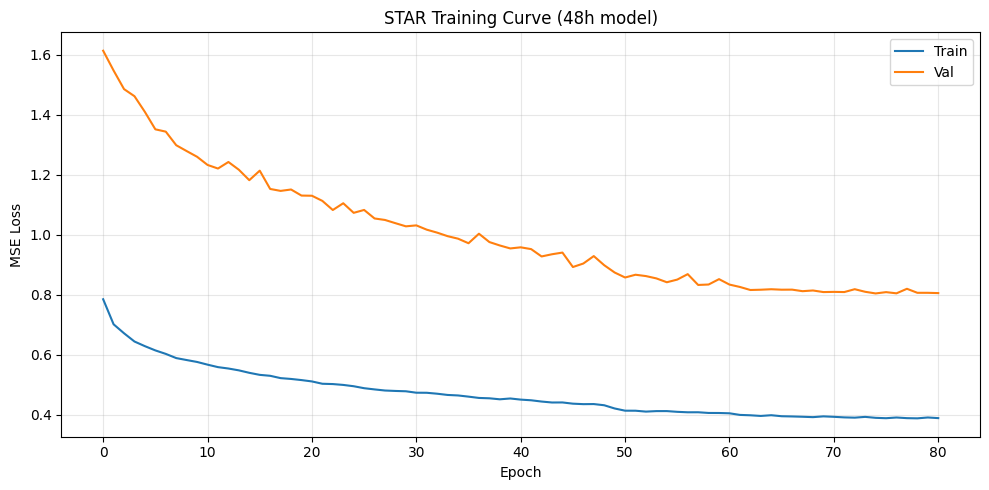

In [190]:
# Training curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(star_history['train'], label='Train')
ax.plot(star_history['val'], label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('STAR Training Curve (48h model)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [191]:
# =====================================================
# STAR: Prediction function
# Predicts 48h, then slices for 24h when needed
# =====================================================

@torch.no_grad()
def predict_star(model, outage_z, weather_pca, timestamps_arr,
                 neighbor_idx, lookback, output_horizon,
                 pred_timestamps, locations, out_mu, out_sd):
    """
    Generate predictions. The model always outputs 48h.
    output_horizon controls how many hours to keep (24 or 48).
    """
    model.eval()
    T_w, L_w = outage_z.shape
    ts_pd = pd.to_datetime(timestamps_arr)
    h = ts_pd.hour.values[-1]
    d = ts_pd.dayofweek.values[-1]
    mean_tracked_normed = np.log1p(mean_tracked)

    rows = []
    for li in range(L_w):
        own = outage_z[-lookback:, li]
        neighbors = neighbor_idx[li]
        neigh = outage_z[-lookback:, neighbors].T
        w = weather_pca[-lookback:, li, :]
        static = np.array([
            np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24),
            np.sin(2*np.pi*d/7), np.cos(2*np.pi*d/7),
            mean_tracked_normed[li]
        ], dtype=np.float32)

        own_t = torch.tensor(own, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        neigh_t = torch.tensor(neigh, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        w_t = torch.tensor(w, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        s_t = torch.tensor(static, dtype=torch.float32).unsqueeze(0).to(DEVICE)

        pred_z = model(own_t, neigh_t, w_t, s_t).cpu().numpy().flatten()  # (48,)
        pred_raw = pred_z * out_sd + out_mu
        pred_raw = np.clip(pred_raw, 0, None)

        # Slice to output_horizon (24 or 48)
        for h_idx in range(output_horizon):
            rows.append({
                'timestamp': pred_timestamps[h_idx],
                'location': str(locations[li]),
                'pred': pred_raw[h_idx]
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(['timestamp', 'location']).reset_index(drop=True)
    return df

In [192]:
# =====================================================
# STAR: Validate
# =====================================================

print("Generating STAR validation predictions...")
star_val_24h_df = predict_star(
    star_model_24h, outage_train_z, weather_train_pca, ts_train,
    neighbor_idx, LOOKBACK, 24, val_24h_ts, locations, out_mu, out_sd
)
star_val_48h_df = predict_star(
    star_model_48h, outage_train_z, weather_train_pca, ts_train,
    neighbor_idx, LOOKBACK, 48, val_48h_ts, locations, out_mu, out_sd
)

star_val_24h_rmses = evaluate_per_county(val_24h_truth, star_val_24h_df, locations)
star_val_48h_rmses = evaluate_per_county(val_48h_truth, star_val_48h_df, locations)

print(f"\nSTAR Validation RMSE:")
print(f"  24h (full model): {np.nanmean(star_val_24h_rmses):.4f}")
print(f"  48h (full model): {np.nanmean(star_val_48h_rmses):.4f}")


Generating STAR validation predictions...

STAR Validation RMSE:
  24h (full model): 101.5375
  48h (full model): 75.6305


In [193]:
# =====================================================
# STAR: Retrain on full data & generate test predictions
# =====================================================

# --- 48h model on full data ---
print("Building 48h windows on full data...")
X_own_f48, X_neigh_f48, X_w_f48, X_s_f48, Y_f48 = build_spatiotemporal_windows(
    outage_full_z, weather_full_pca, timestamps, neighbor_idx, LOOKBACK, STAR_HORIZON
)
n_fs48 = int(len(X_own_f48) * 0.9)
print(f"Total: {len(X_own_f48)}, Train: {n_fs48}, Val: {len(X_own_f48)-n_fs48}")

print("\n=== Retraining STAR 48h on full data ===")
star_final_48h, _ = train_star_model(
    X_own_f48[:n_fs48], X_neigh_f48[:n_fs48], X_w_f48[:n_fs48], X_s_f48[:n_fs48], Y_f48[:n_fs48],
    X_own_f48[n_fs48:], X_neigh_f48[n_fs48:], X_w_f48[n_fs48:], X_s_f48[n_fs48:], Y_f48[n_fs48:],
    horizon=STAR_HORIZON
)

# --- 24h model on full data ---
print("\nBuilding 24h windows on full data for training...")
X_own_f24, X_neigh_f24, X_w_f24, X_s_f24, Y_f24 = build_spatiotemporal_windows(
    outage_full_z, weather_full_pca, timestamps, neighbor_idx, LOOKBACK, 24
)
n_fs24 = int(len(X_own_f24) * 0.9)

print("\n=== Retraining STAR 24h on full data ===")
star_final_24h, _ = train_star_model(
    X_own_f24[:n_fs24], X_neigh_f24[:n_fs24], X_w_f24[:n_fs24], X_s_f24[:n_fs24], Y_f24[:n_fs24],
    X_own_f24[n_fs24:], X_neigh_f24[n_fs24:], X_w_f24[n_fs24:], X_s_f24[n_fs24:], Y_f24[n_fs24:],
    horizon=24
)

# --- Generate test predictions ---
print("\nGenerating STAR test predictions...")
star_test_24h_df = predict_star(
    star_final_24h, outage_full_z, weather_full_pca, timestamps,
    neighbor_idx, LOOKBACK, 24, test_24h_ts, locations, out_mu, out_sd
)
star_test_48h_df = predict_star(
    star_final_48h, outage_full_z, weather_full_pca, timestamps,
    neighbor_idx, LOOKBACK, 48, test_48h_ts, locations, out_mu, out_sd
)

star_test_24h_df.to_csv(f"{RESULTS_DIR}star_pred_24h.csv", index=False)
star_test_48h_df.to_csv(f"{RESULTS_DIR}star_pred_48h.csv", index=False)
print(f"STAR saved: 24h={star_test_24h_df.shape}, 48h={star_test_48h_df.shape}")


Building 48h windows on full data...
Total: 171478, Train: 154330, Val: 17148

=== Retraining STAR 48h on full data ===
  Epoch   1/100 | Train: 1.670517 | Val: 6.538011 | LR: 0.001000 *
  Epoch   2/100 | Train: 1.254002 | Val: 5.449514 | LR: 0.001000 *
  Epoch   3/100 | Train: 1.071302 | Val: 4.714291 | LR: 0.001000 *
  Epoch   4/100 | Train: 1.002850 | Val: 5.521818 | LR: 0.001000
  Epoch   5/100 | Train: 0.917845 | Val: 4.645148 | LR: 0.001000 *
  Epoch   6/100 | Train: 0.854539 | Val: 6.817257 | LR: 0.001000
  Epoch   7/100 | Train: 0.820299 | Val: 4.514652 | LR: 0.001000 *
  Epoch   8/100 | Train: 0.801609 | Val: 5.475989 | LR: 0.001000
  Epoch   9/100 | Train: 0.757878 | Val: 4.849341 | LR: 0.001000
  Epoch  10/100 | Train: 0.747620 | Val: 5.739876 | LR: 0.000500
  Epoch  11/100 | Train: 0.696698 | Val: 4.502720 | LR: 0.000500 *
  Epoch  12/100 | Train: 0.679664 | Val: 4.067601 | LR: 0.000500 *
  Epoch  13/100 | Train: 0.682728 | Val: 3.716838 | LR: 0.000500 *
  Epoch  14/100 | T

---
---
# MODEL C: SARIMAX (Per-County Persistence)

In [194]:
# =====================================================
# SARIMAX: Fit per county
# =====================================================

SARIMAX_ORDER = (1, 0, 1)

def safe_fit_sarimax(y, order=(1, 0, 1)):
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    y = np.asarray(y, dtype=float).flatten()
    if len(y) < 8 or np.allclose(y, y[0]):
        return None
    try:
        model = SARIMAX(y, order=order, enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        return res
    except Exception as e:
        print(f"  Warning: fit failed - {str(e)[:50]}")
        return None

def generate_sarimax_predictions(models_dict, locations, timestamps):
    rows = []
    n_steps = len(timestamps)
    for loc in locations:
        loc_str = str(loc)
        if loc_str in models_dict and models_dict[loc_str] is not None:
            try:
                pred = np.asarray(models_dict[loc_str].forecast(steps=n_steps), dtype=float)
                pred = np.clip(pred, 0, None)
            except:
                pred = np.zeros(n_steps)
        else:
            pred = np.zeros(n_steps)
        rows.append(pd.DataFrame({
            "timestamp": timestamps, "location": loc_str, "pred": pred
        }))
    return pd.concat(rows, ignore_index=True)

In [195]:
# =====================================================
# SARIMAX: Train & validate
# =====================================================

print("Training SARIMAX on training subset...")
sarimax_val_models = {}
for loc in tqdm(locations, desc="SARIMAX fit"):
    loc_str = str(loc)
    y = outage_train[:, locations.index(loc_str)].flatten()
    sarimax_val_models[loc_str] = safe_fit_sarimax(y, order=SARIMAX_ORDER)

n_success = sum(1 for v in sarimax_val_models.values() if v is not None)
print(f"Fitted: {n_success}/{L} counties")

print("\nGenerating SARIMAX validation predictions...")
sarimax_val_24h_df = generate_sarimax_predictions(sarimax_val_models, locations, val_24h_ts)
sarimax_val_48h_df = generate_sarimax_predictions(sarimax_val_models, locations, val_48h_ts)

sarimax_val_24h_rmses = evaluate_per_county(val_24h_truth, sarimax_val_24h_df, locations)
sarimax_val_48h_rmses = evaluate_per_county(val_48h_truth, sarimax_val_48h_df, locations)

print(f"\nSARIMAX Validation RMSE:")
print(f"  24h: {np.nanmean(sarimax_val_24h_rmses):.4f}")
print(f"  48h: {np.nanmean(sarimax_val_48h_rmses):.4f}")

Training SARIMAX on training subset...


SARIMAX fit:   0%|          | 0/83 [00:00<?, ?it/s]

Fitted: 83/83 counties

Generating SARIMAX validation predictions...

SARIMAX Validation RMSE:
  24h: 89.7450
  48h: 68.3606


In [196]:
# =====================================================
# SARIMAX: Retrain on full data & generate test predictions
# =====================================================

print("Training SARIMAX on full data...")
sarimax_final_models = {}
for loc in tqdm(locations, desc="SARIMAX full fit"):
    loc_str = str(loc)
    y = outage[:, locations.index(loc_str)].flatten()
    sarimax_final_models[loc_str] = safe_fit_sarimax(y, order=SARIMAX_ORDER)

sarimax_test_24h_df = generate_sarimax_predictions(sarimax_final_models, locations, test_24h_ts)
sarimax_test_48h_df = generate_sarimax_predictions(sarimax_final_models, locations, test_48h_ts)

sarimax_test_24h_df.to_csv(f"{RESULTS_DIR}sarimax_pred_24h.csv", index=False)
sarimax_test_48h_df.to_csv(f"{RESULTS_DIR}sarimax_pred_48h.csv", index=False)
print(f"SARIMAX saved: 24h={sarimax_test_24h_df.shape}, 48h={sarimax_test_48h_df.shape}")

Training SARIMAX on full data...


SARIMAX full fit:   0%|          | 0/83 [00:00<?, ?it/s]

SARIMAX saved: 24h=(1992, 3), 48h=(3984, 3)


---
---
# MODEL D: LightGBM (Single model, all horizons)
Uses log1p target transform, location as categorical, horizon as feature.
One model handles all counties and all horizons simultaneously.

In [197]:
!pip install lightgbm -q
import lightgbm as lgb
print('LightGBM imported successfully')

LightGBM imported successfully


In [198]:
# =====================================================
# LightGBM: Feature engineering
# =====================================================

LGB_KEY_WEATHER = [
    't2m', 'd2m', 'sp', 'tp', 'prate', 'gust', 'max_10si',
    'u10', 'v10', 'r2', 'tcc', 'cape', 'blh',
    'crain', 'csnow', 'refc', 'sdswrf', 'pwat',
]
LGB_KEY_WEATHER = [f for f in LGB_KEY_WEATHER if f in features]
print(f"LightGBM using {len(LGB_KEY_WEATHER)} weather features: {LGB_KEY_WEATHER}")

LGB_LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 168]
LGB_ROLL_WINDOWS = [6, 24, 72, 168]
LGB_NUM_BOOST_ROUND = 500
LGB_NUM_LEAVES = 63
LGB_LEARNING_RATE = 0.05
LGB_MIN_DATA_IN_LEAF = 50


def lgb_precompute_features(outage_arr, tracked_arr, weather_arr, timestamps_arr):
    """Precompute lag and rolling features."""
    weather_idx = [features.index(f) for f in LGB_KEY_WEATHER]
    wx_sub = weather_arr[:, :, weather_idx]
    T_, L_ = outage_arr.shape
    F_ = wx_sub.shape[2]

    lag_arrs = {}
    for lag_val in LGB_LAGS:
        arr = np.full_like(outage_arr, np.nan)
        if lag_val < T_:
            arr[lag_val:] = outage_arr[:T_ - lag_val]
        lag_arrs[lag_val] = arr

    out_df = pd.DataFrame(outage_arr)
    roll_mean = {w: out_df.rolling(w, min_periods=1).mean().values for w in LGB_ROLL_WINDOWS}
    roll_max = {w: out_df.rolling(w, min_periods=1).max().values for w in LGB_ROLL_WINDOWS}
    roll_std = {w: out_df.rolling(w, min_periods=1).std(ddof=0).fillna(0).values for w in LGB_ROLL_WINDOWS}

    wx_roll_mean, wx_roll_max = {}, {}
    wx_flat = wx_sub.reshape(T_, L_ * F_)
    wx_df = pd.DataFrame(wx_flat)
    for w in [24, 72]:
        wx_roll_mean[w] = wx_df.rolling(w, min_periods=1).mean().values.reshape(T_, L_, F_)
        wx_roll_max[w] = wx_df.rolling(w, min_periods=1).max().values.reshape(T_, L_, F_)

    ts = pd.to_datetime(timestamps_arr)
    county_mean = outage_arr.mean(axis=0)
    county_std = outage_arr.std(axis=0)
    county_median = np.median(outage_arr, axis=0)
    county_q75 = np.quantile(outage_arr, 0.75, axis=0)

    return dict(
        out=outage_arr, tracked=tracked_arr, wx=wx_sub,
        lag_arrs=lag_arrs, roll_mean=roll_mean, roll_max=roll_max, roll_std=roll_std,
        wx_roll_mean=wx_roll_mean, wx_roll_max=wx_roll_max,
        ts=ts, ts_hour=ts.hour.values, ts_dow=ts.dayofweek.values,
        county_mean=county_mean, county_std=county_std,
        county_median=county_median, county_q75=county_q75,
        T=T_, L=L_, F=F_,
    )


def lgb_assemble_features(state, origin_t_arr, loc_arr, horizon_arr, target_ts_arr):
    """Build feature DataFrame for a batch of (origin, location, horizon, target_ts)."""
    origin_t_arr = np.asarray(origin_t_arr)
    loc_arr = np.asarray(loc_arr)
    horizon_arr = np.asarray(horizon_arr)
    feats = {}
    for lag_val in LGB_LAGS:
        feats[f'out_lag_{lag_val}'] = state['lag_arrs'][lag_val][origin_t_arr, loc_arr]
    for w in LGB_ROLL_WINDOWS:
        feats[f'out_roll_mean_{w}'] = state['roll_mean'][w][origin_t_arr, loc_arr]
        feats[f'out_roll_max_{w}'] = state['roll_max'][w][origin_t_arr, loc_arr]
        feats[f'out_roll_std_{w}'] = state['roll_std'][w][origin_t_arr, loc_arr]
    feats['tracked'] = state['tracked'][origin_t_arr, loc_arr]
    feats['county_mean'] = state['county_mean'][loc_arr]
    feats['county_std'] = state['county_std'][loc_arr]
    feats['county_median'] = state['county_median'][loc_arr]
    feats['county_q75'] = state['county_q75'][loc_arr]
    wx_cur = state['wx'][origin_t_arr, loc_arr, :]
    for j, name in enumerate(LGB_KEY_WEATHER):
        feats[f'wx_{name}'] = wx_cur[:, j]
    for w in [24, 72]:
        wxm = state['wx_roll_mean'][w][origin_t_arr, loc_arr, :]
        wxmx = state['wx_roll_max'][w][origin_t_arr, loc_arr, :]
        for j, name in enumerate(LGB_KEY_WEATHER):
            feats[f'wx_{name}_mean_{w}'] = wxm[:, j]
            feats[f'wx_{name}_max_{w}'] = wxmx[:, j]
    target_ts_arr = pd.DatetimeIndex(target_ts_arr)
    t_hour = target_ts_arr.hour.values
    t_dow = target_ts_arr.dayofweek.values
    feats['target_hour'] = t_hour
    feats['target_hour_sin'] = np.sin(2 * np.pi * t_hour / 24)
    feats['target_hour_cos'] = np.cos(2 * np.pi * t_hour / 24)
    feats['target_dow'] = t_dow
    feats['origin_hour'] = state['ts_hour'][origin_t_arr]
    feats['horizon'] = horizon_arr
    feats['location_idx'] = loc_arr
    return pd.DataFrame(feats)

print("LightGBM feature functions defined.")

LightGBM using 18 weather features: ['t2m', 'd2m', 'sp', 'tp', 'prate', 'gust', 'max_10si', 'u10', 'v10', 'r2', 'tcc', 'cape', 'blh', 'crain', 'csnow', 'refc', 'sdswrf', 'pwat']
LightGBM feature functions defined.


In [199]:
# =====================================================
# LightGBM: Training & prediction functions
# =====================================================

def lgb_build_training_set(state, min_t, max_t, max_horizon, seed=RANDOM_SEED):
    """Build (X, y) from ALL valid origins (not sampled) for deterministic results."""
    L_ = state['L']
    ts = state['ts']
    out = state['out']
    T_ = state['T']
    all_origins, all_horizons, all_locs, all_targets, all_target_ts = [], [], [], [], []
    # Use every valid origin (subsample if too large)
    candidates = np.arange(min_t, min(max_t + 1, T_ - max_horizon))
    # Subsample origins to keep memory manageable
    rng = np.random.RandomState(seed)
    max_origins = 500
    if len(candidates) > max_origins:
        origins = rng.choice(candidates, size=max_origins, replace=False)
        origins = np.sort(origins)
    else:
        origins = candidates
    for t in origins:
        for h in range(1, max_horizon + 1):
            target_idx = t + h
            if target_idx >= T_:
                continue
            target_ts = ts[target_idx]
            for li in range(L_):
                all_origins.append(t)
                all_horizons.append(h)
                all_locs.append(li)
                all_targets.append(out[target_idx, li])
                all_target_ts.append(target_ts)
    all_targets = np.array(all_targets, dtype=float)
    X = lgb_assemble_features(state, np.array(all_origins), np.array(all_locs),
                              np.array(all_horizons), np.array(all_target_ts))
    y_log = np.log1p(np.clip(all_targets, 0, None))
    return X, y_log


def lgb_train(X, y_log, num_boost_round=LGB_NUM_BOOST_ROUND):
    """Train a single LightGBM model across all locations and horizons."""
    params = dict(
        objective='regression', metric='rmse',
        num_leaves=LGB_NUM_LEAVES, learning_rate=LGB_LEARNING_RATE,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        min_data_in_leaf=LGB_MIN_DATA_IN_LEAF,
        verbose=-1, num_threads=-1, seed=RANDOM_SEED,
    )
    cat_feats = ['location_idx', 'horizon', 'target_hour', 'target_dow', 'origin_hour']
    dtrain = lgb.Dataset(X, label=y_log, categorical_feature=cat_feats)
    model = lgb.train(params, dtrain, num_boost_round=num_boost_round)
    return model


def lgb_predict(model, state, origin_t, target_timestamps, locations_list, horizons):
    """Predict outages for all (location, horizon) at a given origin time."""
    L_ = state['L']
    n_h = len(horizons)
    pred_origins = np.full(n_h * L_, origin_t)
    pred_horizons = np.repeat(horizons, L_)
    pred_locs = np.tile(np.arange(L_), n_h)
    pred_target_ts = np.repeat(target_timestamps, L_)
    X_pred = lgb_assemble_features(state, pred_origins, pred_locs, pred_horizons, pred_target_ts)
    X_pred = X_pred[model.feature_name()]
    log_pred = model.predict(X_pred)
    pred = np.clip(np.expm1(log_pred), 0, None)
    pred_2d = pred.reshape(n_h, L_)
    rows = []
    for i, loc in enumerate(locations_list):
        rows.append(pd.DataFrame({
            'timestamp': target_timestamps,
            'location': str(loc), 'pred': pred_2d[:, i],
        }))
    df = pd.concat(rows, ignore_index=True)
    return df.sort_values(['timestamp', 'location']).reset_index(drop=True)

print("LightGBM train + predict functions defined.")

LightGBM train + predict functions defined.


In [200]:
# =====================================================
# LightGBM: Precompute, train, validate
# =====================================================

print("Precomputing LightGBM features (train subset)...")
lgb_state_train = lgb_precompute_features(outage_train, tracked[:split_idx], weather_train, ts_train)

# Need enough lags — start from index 168 (1 week)
min_t_train = max(LGB_LAGS)  # 168
max_t_train = lgb_state_train['T'] - 49  # leave room for 48h targets

print(f"Building LightGBM training set (origins {min_t_train} to {max_t_train})...")
X_lgb_train, y_lgb_train = lgb_build_training_set(lgb_state_train, min_t_train, max_t_train, 48)
print(f"  Training samples: {len(y_lgb_train):,}")

print("Training LightGBM...")
lgb_model_val = lgb_train(X_lgb_train, y_lgb_train)

# Validate
print("\nGenerating LightGBM validation predictions...")
origin_t_val = lgb_state_train['T'] - 1  # last available training timestamp

lgb_val_24h_df = lgb_predict(
    lgb_model_val, lgb_state_train, origin_t_val,
    val_24h_ts, locations, np.arange(1, 25)
)
lgb_val_48h_df = lgb_predict(
    lgb_model_val, lgb_state_train, origin_t_val,
    val_48h_ts, locations, np.arange(1, 49)
)

lgb_val_24h_rmses = evaluate_per_county(val_24h_truth, lgb_val_24h_df, locations)
lgb_val_48h_rmses = evaluate_per_county(val_48h_truth, lgb_val_48h_df, locations)

print(f"\nLightGBM Validation RMSE:")
print(f"  24h: {np.nanmean(lgb_val_24h_rmses):.4f}")
print(f"  48h: {np.nanmean(lgb_val_48h_rmses):.4f}")

Precomputing LightGBM features (train subset)...
Building LightGBM training set (origins 168 to 1679)...
  Training samples: 1,992,000
Training LightGBM...

Generating LightGBM validation predictions...

LightGBM Validation RMSE:
  24h: 94.6017
  48h: 71.0916


In [201]:
# =====================================================
# LightGBM: Retrain on full data & generate test predictions
# =====================================================

print("Precomputing LightGBM features (full data)...")
lgb_state_full = lgb_precompute_features(outage, tracked, weather, timestamps)

min_t_full = max(LGB_LAGS)
max_t_full = lgb_state_full['T'] - 49

print("Building LightGBM training set (full)...")
X_lgb_full, y_lgb_full = lgb_build_training_set(lgb_state_full, min_t_full, max_t_full, 48)
print(f"  Training samples: {len(y_lgb_full):,}")

print("Training LightGBM on full data...")
lgb_model_final = lgb_train(X_lgb_full, y_lgb_full)

origin_t_test = lgb_state_full['T'] - 1

print("Generating LightGBM test predictions...")
lgb_test_24h_df = lgb_predict(
    lgb_model_final, lgb_state_full, origin_t_test,
    test_24h_ts, locations, np.arange(1, 25)
)
lgb_test_48h_df = lgb_predict(
    lgb_model_final, lgb_state_full, origin_t_test,
    test_48h_ts, locations, np.arange(1, 49)
)

lgb_test_24h_df.to_csv(f"{RESULTS_DIR}lgb_pred_24h.csv", index=False)
lgb_test_48h_df.to_csv(f"{RESULTS_DIR}lgb_pred_48h.csv", index=False)
print(f"LightGBM saved: 24h={lgb_test_24h_df.shape}, 48h={lgb_test_48h_df.shape}")

Precomputing LightGBM features (full data)...
Building LightGBM training set (full)...
  Training samples: 1,992,000
Training LightGBM on full data...
Generating LightGBM test predictions...
LightGBM saved: 24h=(1992, 3), 48h=(3984, 3)


---
---
# MODEL E: Exponential Smoothing (Per-County)

In [202]:
# =====================================================
# Exponential Smoothing: Per-county forecast
# Simpler than SARIMAX — weighted average of past values
# with exponentially decaying weights.
# =====================================================

def exp_smoothing_forecast(y, alpha, horizon):
    """
    Simple exponential smoothing.
    Forecast = last smoothed value (flat forecast).
    alpha: smoothing factor (0-1). Higher = more weight on recent.
    """
    y = np.asarray(y, dtype=float).flatten()
    if len(y) == 0:
        return np.zeros(horizon)
    s = y[0]
    for val in y[1:]:
        s = alpha * val + (1 - alpha) * s
    return np.full(horizon, max(s, 0))

def generate_es_predictions(outage_arr, locations, pred_timestamps, alpha, horizon):
    rows = []
    for li, loc in enumerate(locations):
        loc_str = str(loc)
        y = outage_arr[:, li].flatten()
        pred = exp_smoothing_forecast(y, alpha, horizon)
        rows.append(pd.DataFrame({
            'timestamp': pred_timestamps,
            'location': loc_str,
            'pred': pred
        }))
    return pd.concat(rows, ignore_index=True)

# Find best alpha on validation
print("Tuning exponential smoothing alpha...")
best_alpha_24, best_es_24 = 0.1, float('inf')
best_alpha_48, best_es_48 = 0.1, float('inf')

for alpha in np.arange(0.05, 1.0, 0.05):
    es_24_df = generate_es_predictions(outage_train, locations, val_24h_ts, alpha, 24)
    es_48_df = generate_es_predictions(outage_train, locations, val_48h_ts, alpha, 48)
    r24 = np.nanmean(evaluate_per_county(val_24h_truth, es_24_df, locations))
    r48 = np.nanmean(evaluate_per_county(val_48h_truth, es_48_df, locations))
    if r24 < best_es_24:
        best_es_24 = r24
        best_alpha_24 = alpha
    if r48 < best_es_48:
        best_es_48 = r48
        best_alpha_48 = alpha

print(f"Best alpha 24h: {best_alpha_24:.2f} -> RMSE: {best_es_24:.4f}")
print(f"Best alpha 48h: {best_alpha_48:.2f} -> RMSE: {best_es_48:.4f}")

# Generate validation predictions with best alphas
es_val_24h_df = generate_es_predictions(outage_train, locations, val_24h_ts, best_alpha_24, 24)
es_val_48h_df = generate_es_predictions(outage_train, locations, val_48h_ts, best_alpha_48, 48)
es_val_24h_rmses = evaluate_per_county(val_24h_truth, es_val_24h_df, locations)
es_val_48h_rmses = evaluate_per_county(val_48h_truth, es_val_48h_df, locations)

print(f"\nExpSmooth Validation RMSE:")
print(f"  24h: {np.nanmean(es_val_24h_rmses):.4f}")
print(f"  48h: {np.nanmean(es_val_48h_rmses):.4f}")

Tuning exponential smoothing alpha...
Best alpha 24h: 0.05 -> RMSE: 104.5648
Best alpha 48h: 0.05 -> RMSE: 83.1857

ExpSmooth Validation RMSE:
  24h: 104.5648
  48h: 83.1857


In [203]:
# ExpSmooth: Generate test predictions
es_test_24h_df = generate_es_predictions(outage, locations, test_24h_ts, best_alpha_24, 24)
es_test_48h_df = generate_es_predictions(outage, locations, test_48h_ts, best_alpha_48, 48)

es_test_24h_df.to_csv(f"{RESULTS_DIR}es_pred_24h.csv", index=False)
es_test_48h_df.to_csv(f"{RESULTS_DIR}es_pred_48h.csv", index=False)
print(f"ExpSmooth saved: 24h={es_test_24h_df.shape}, 48h={es_test_48h_df.shape}")

ExpSmooth saved: 24h=(1992, 3), 48h=(3984, 3)


---
---
# COMPARISON: All 5 Models

In [204]:
# Zero baseline
z_24 = np.mean([rmse(val_24h_truth[:, i], np.zeros(24)) for i in range(L)])
z_48 = np.mean([rmse(val_48h_truth[:, i], np.zeros(48)) for i in range(L)])

s_24 = np.nanmean(sarimax_val_24h_rmses)
s_48 = np.nanmean(sarimax_val_48h_rmses)
x_24 = np.nanmean(xgb_val_24h_rmses)
x_48 = np.nanmean(xgb_val_48h_rmses)
st_24 = np.nanmean(star_val_24h_rmses)
st_48 = np.nanmean(star_val_48h_rmses)
lg_24 = np.nanmean(lgb_val_24h_rmses)
lg_48 = np.nanmean(lgb_val_48h_rmses)
e_24 = np.nanmean(es_val_24h_rmses)
e_48 = np.nanmean(es_val_48h_rmses)

print("="*55)
print("VALIDATION RMSE — ALL MODELS")
print("="*55)
print(f"{'Model':<20} {'24h RMSE':>12} {'48h RMSE':>12}")
print("-"*48)
print(f"{'SARIMAX':<20} {s_24:>12.4f} {s_48:>12.4f}")
print(f"{'XGBoost':<20} {x_24:>12.4f} {x_48:>12.4f}")
print(f"{'STAR':<20} {st_24:>12.4f} {st_48:>12.4f}")
print(f"{'LightGBM':<20} {lg_24:>12.4f} {lg_48:>12.4f}")
print(f"{'ExpSmooth':<20} {e_24:>12.4f} {e_48:>12.4f}")
print(f"{'Zero Baseline':<20} {z_24:>12.4f} {z_48:>12.4f}")
print("="*55)

VALIDATION RMSE — ALL MODELS
Model                    24h RMSE     48h RMSE
------------------------------------------------
SARIMAX                   89.7450      68.3606
XGBoost                   96.6404      78.0673
STAR                     101.5375      75.6305
LightGBM                  94.6017      71.0916
ExpSmooth                104.5648      83.1857
Zero Baseline            100.3053      75.3561


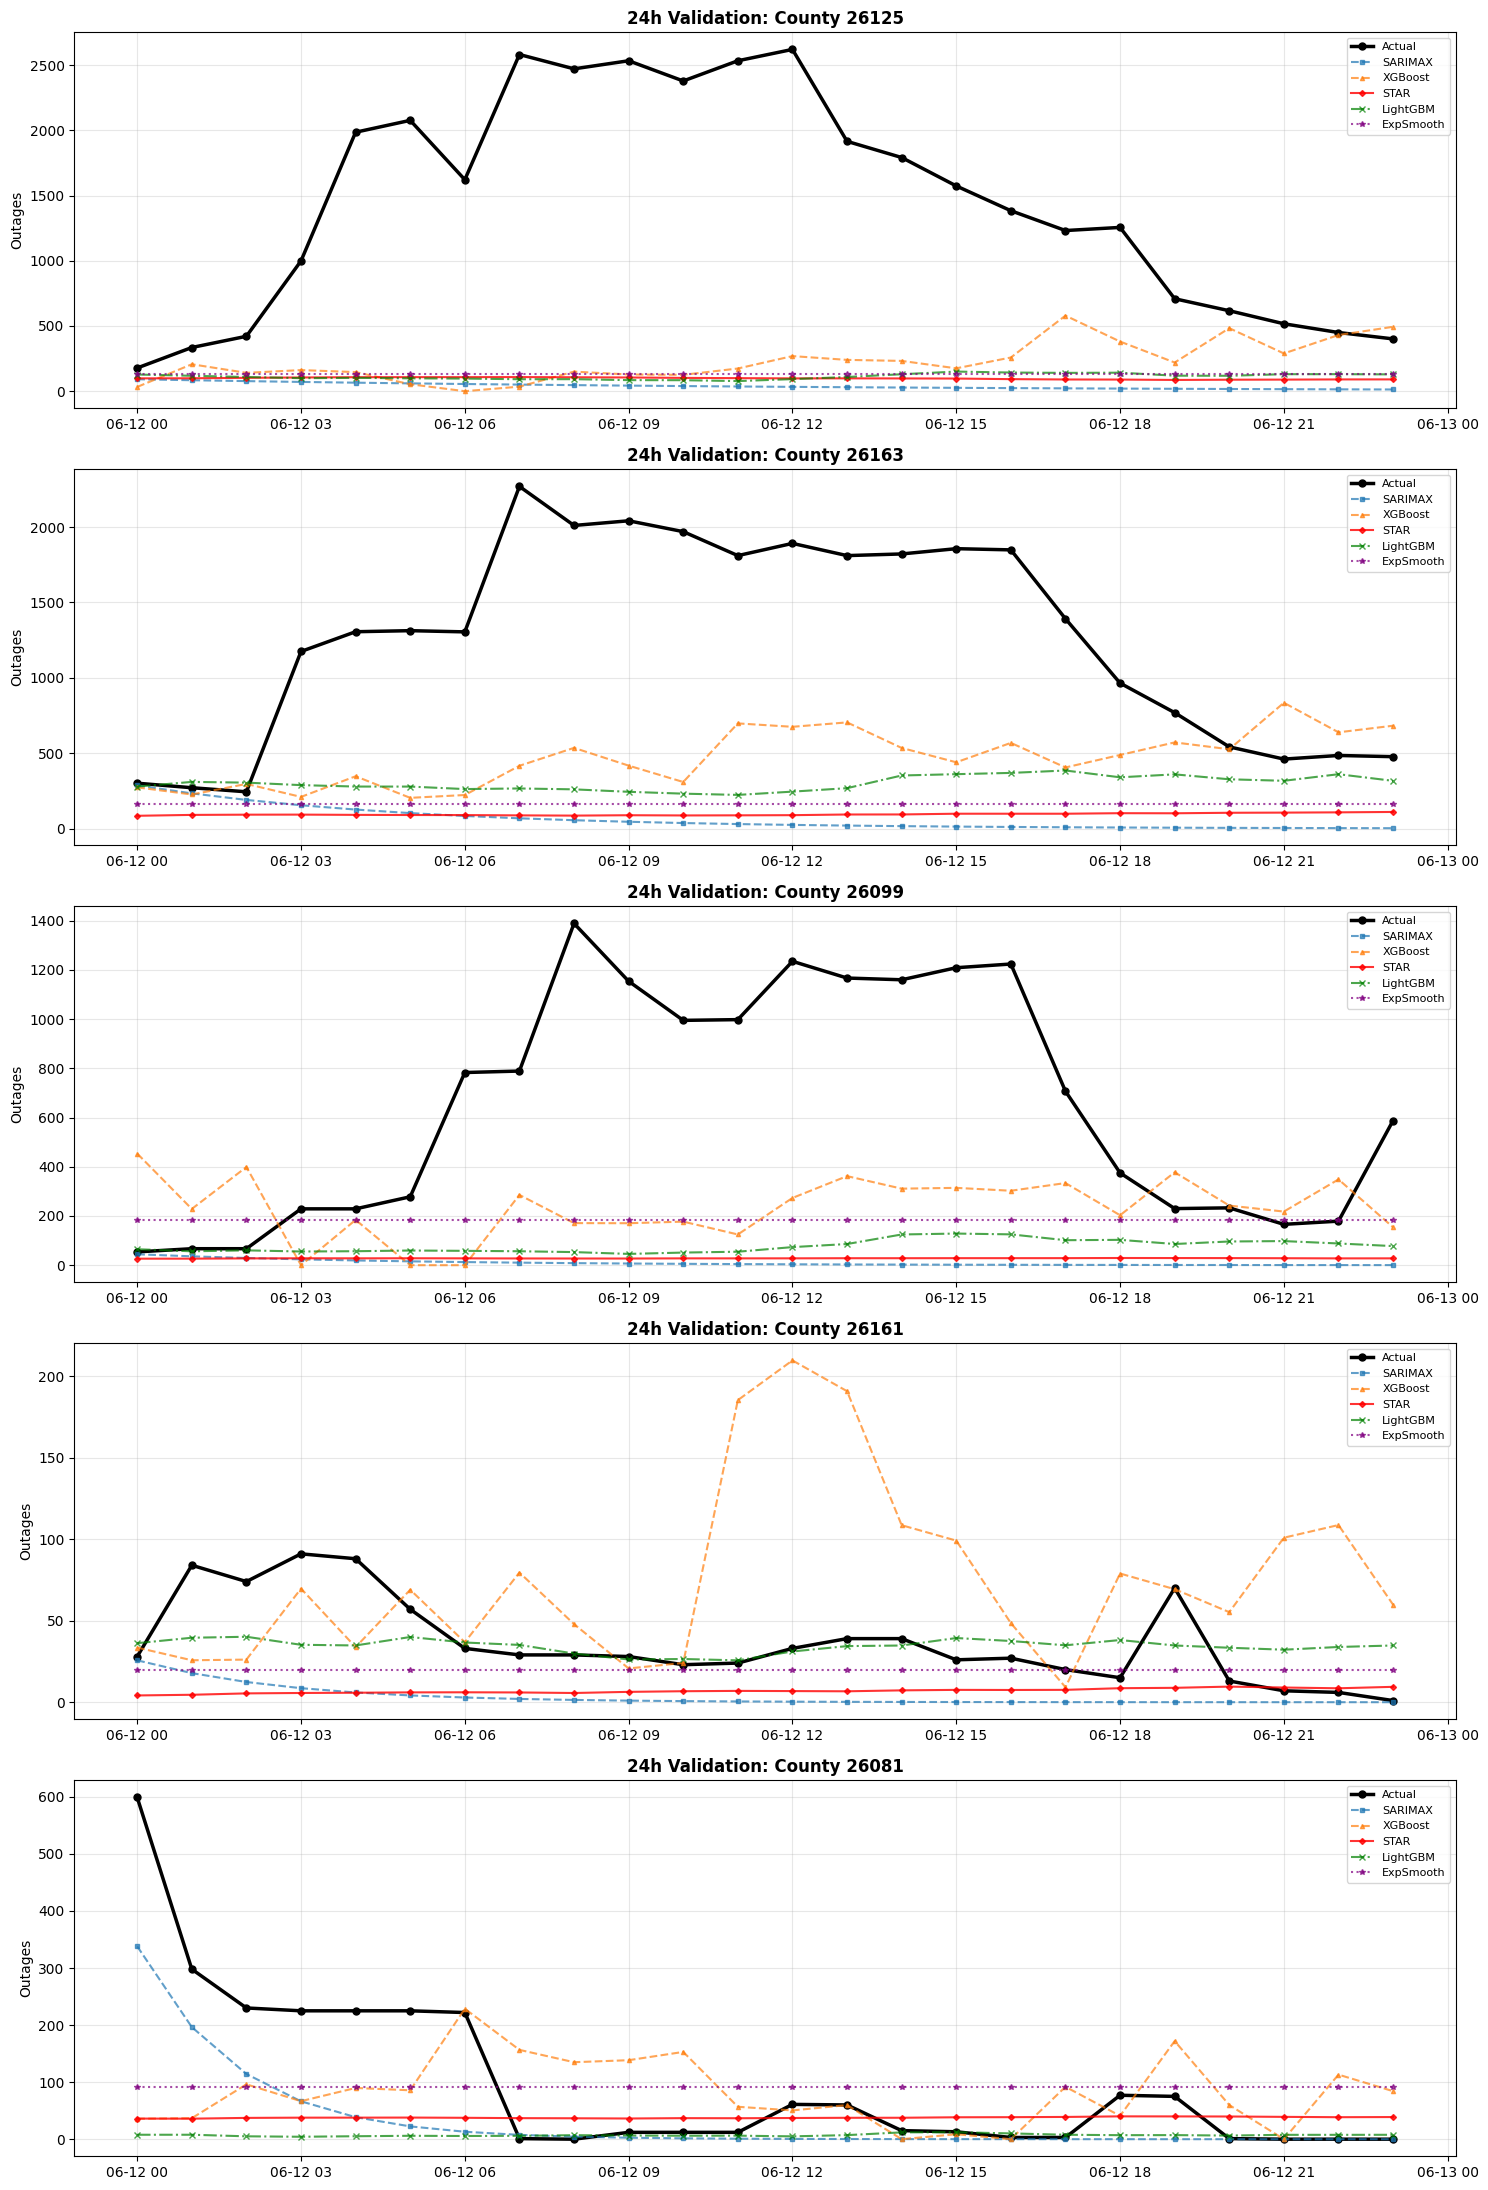

In [205]:
# Visualize predictions for top 5 counties (24h)
top5 = np.argsort(np.nanmean(outage, axis=0))[::-1][:5]

fig, axes = plt.subplots(5, 1, figsize=(15, 22))
for plot_idx, li in enumerate(top5):
    ax = axes[plot_idx]
    loc_str = str(locations[li])

    s_pred = sarimax_val_24h_df[sarimax_val_24h_df['location'] == loc_str]['pred'].values
    x_pred = xgb_val_24h_df[xgb_val_24h_df['location'] == loc_str]['pred'].values
    st_pred = star_val_24h_df[star_val_24h_df['location'] == loc_str]['pred'].values
    lg_pred = lgb_val_24h_df[lgb_val_24h_df['location'] == loc_str]['pred'].values
    e_pred = es_val_24h_df[es_val_24h_df['location'] == loc_str]['pred'].values

    ax.plot(val_24h_ts, val_24h_truth[:, li], 'k-o', label='Actual', linewidth=2.5, markersize=5)
    ax.plot(val_24h_ts, s_pred, 's--', label='SARIMAX', alpha=0.7, markersize=3)
    ax.plot(val_24h_ts, x_pred, '^--', label='XGBoost', alpha=0.7, markersize=3)
    ax.plot(val_24h_ts, st_pred, 'D-', label='STAR', alpha=0.8, markersize=3, color='red')
    ax.plot(val_24h_ts, lg_pred, 'x-.', label='LightGBM', alpha=0.7, markersize=4, color='green')
    ax.plot(val_24h_ts, e_pred, '*:', label='ExpSmooth', alpha=0.7, markersize=4, color='purple')

    ax.set_title(f'24h Validation: County {loc_str}', fontweight='bold')
    ax.set_ylabel('Outages')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
---
# ENSEMBLE: Weighted Average + Per-County Selection

In [206]:
# =====================================================
# 5-model weighted ensemble grid search
# =====================================================

def ensemble_5_predictions(df_s, df_x, df_st, df_lg, df_e, w_s, w_x, w_st, w_lg, w_e):
    df = df_s.copy().sort_values(['timestamp', 'location']).reset_index(drop=True)
    pred_s = df['pred'].values
    pred_x = df_x.sort_values(['timestamp', 'location']).reset_index(drop=True)['pred'].values
    pred_st = df_st.sort_values(['timestamp', 'location']).reset_index(drop=True)['pred'].values
    pred_lg = df_lg.sort_values(['timestamp', 'location']).reset_index(drop=True)['pred'].values
    pred_e = df_e.sort_values(['timestamp', 'location']).reset_index(drop=True)['pred'].values
    df['pred'] = w_s*pred_s + w_x*pred_x + w_st*pred_st + w_lg*pred_lg + w_e*pred_e
    df['pred'] = df['pred'].clip(lower=0)
    return df

print("Searching for optimal 5-model ensemble weights...")
step = 0.1
best_w_24 = (0.2,)*5
best_rmse_24 = float('inf')
best_w_48 = (0.2,)*5
best_rmse_48 = float('inf')

for w_s in np.arange(0.0, 1.0 + step, step):
    for w_x in np.arange(0.0, 1.0 - w_s + step, step):
        for w_st in np.arange(0.0, 1.0 - w_s - w_x + step, step):
            for w_lg in np.arange(0.0, 1.0 - w_s - w_x - w_st + step, step):
                w_e = 1.0 - w_s - w_x - w_st - w_lg
                if w_e < -0.01:
                    continue
                w_e = max(w_e, 0.0)
                ens_24 = ensemble_5_predictions(
                    sarimax_val_24h_df, xgb_val_24h_df, star_val_24h_df,
                    lgb_val_24h_df, es_val_24h_df,
                    w_s, w_x, w_st, w_lg, w_e)
                r24 = np.nanmean(evaluate_per_county(val_24h_truth, ens_24, locations))
                if r24 < best_rmse_24:
                    best_rmse_24 = r24
                    best_w_24 = (w_s, w_x, w_st, w_lg, w_e)
                ens_48 = ensemble_5_predictions(
                    sarimax_val_48h_df, xgb_val_48h_df, star_val_48h_df,
                    lgb_val_48h_df, es_val_48h_df,
                    w_s, w_x, w_st, w_lg, w_e)
                r48 = np.nanmean(evaluate_per_county(val_48h_truth, ens_48, locations))
                if r48 < best_rmse_48:
                    best_rmse_48 = r48
                    best_w_48 = (w_s, w_x, w_st, w_lg, w_e)

print(f"\n24h Best: SAR={best_w_24[0]:.1f}, XGB={best_w_24[1]:.1f}, STAR={best_w_24[2]:.1f}, LGB={best_w_24[3]:.1f}, ES={best_w_24[4]:.1f} -> RMSE={best_rmse_24:.4f}")
print(f"48h Best: SAR={best_w_48[0]:.1f}, XGB={best_w_48[1]:.1f}, STAR={best_w_48[2]:.1f}, LGB={best_w_48[3]:.1f}, ES={best_w_48[4]:.1f} -> RMSE={best_rmse_48:.4f}")

Searching for optimal 5-model ensemble weights...

24h Best: SAR=0.6, XGB=0.2, STAR=0.0, LGB=0.2, ES=0.0 -> RMSE=86.1580
48h Best: SAR=0.6, XGB=0.1, STAR=0.0, LGB=0.3, ES=0.0 -> RMSE=65.7230


In [207]:
# =====================================================
# Per-county model selection (5 models)
# =====================================================

def per_county_selection(val_truth, val_dfs, val_labels, test_dfs, locations, horizon):
    n_models = len(val_dfs)
    county_best = {}
    for i, loc in enumerate(locations):
        loc_str = str(loc)
        best_idx, best_r = 0, float('inf')
        for m_idx in range(n_models):
            loc_pred = val_dfs[m_idx][val_dfs[m_idx]['location'].astype(str) == loc_str]['pred'].values
            if len(loc_pred) == horizon:
                r = rmse(val_truth[:, i], loc_pred)
                if r < best_r:
                    best_r = r
                    best_idx = m_idx
        county_best[loc_str] = (best_idx, best_r)
    rows = []
    for loc in locations:
        loc_str = str(loc)
        best_idx = county_best[loc_str][0]
        rows.append(test_dfs[best_idx][test_dfs[best_idx]['location'].astype(str) == loc_str])
    result_df = pd.concat(rows, ignore_index=True)
    result_df = result_df.sort_values(['timestamp', 'location']).reset_index(drop=True)
    return result_df, county_best

model_labels = ['SARIMAX', 'XGBoost', 'STAR', 'LightGBM', 'ExpSmooth']

val_dfs_24 = [sarimax_val_24h_df, xgb_val_24h_df, star_val_24h_df, lgb_val_24h_df, es_val_24h_df]
test_dfs_24 = [sarimax_test_24h_df, xgb_test_24h_df, star_test_24h_df, lgb_test_24h_df, es_test_24h_df]
pc_test_24h_df, county_best_24 = per_county_selection(
    val_24h_truth, val_dfs_24, model_labels, test_dfs_24, locations, 24)

val_dfs_48 = [sarimax_val_48h_df, xgb_val_48h_df, star_val_48h_df, lgb_val_48h_df, es_val_48h_df]
test_dfs_48 = [sarimax_test_48h_df, xgb_test_48h_df, star_test_48h_df, lgb_test_48h_df, es_test_48h_df]
pc_test_48h_df, county_best_48 = per_county_selection(
    val_48h_truth, val_dfs_48, model_labels, test_dfs_48, locations, 48)

pc_val_24h_rmse = np.mean([county_best_24[str(loc)][1] for loc in locations])
pc_val_48h_rmse = np.mean([county_best_48[str(loc)][1] for loc in locations])

from collections import Counter
dist_24 = Counter(county_best_24[str(loc)][0] for loc in locations)
dist_48 = Counter(county_best_48[str(loc)][0] for loc in locations)

print("Per-county model selection results:")
print(f"  24h RMSE: {pc_val_24h_rmse:.4f}")
print(f"  48h RMSE: {pc_val_48h_rmse:.4f}")
print(f"\n24h model distribution:")
for idx, count in sorted(dist_24.items()):
    print(f"  {model_labels[idx]}: {count} counties")
print(f"\n48h model distribution:")
for idx, count in sorted(dist_48.items()):
    print(f"  {model_labels[idx]}: {count} counties")

pc_test_24h_df.to_csv(f"{RESULTS_DIR}percounty_pred_24h.csv", index=False)
pc_test_48h_df.to_csv(f"{RESULTS_DIR}percounty_pred_48h.csv", index=False)
print(f"\nPer-county saved: 24h={pc_test_24h_df.shape}, 48h={pc_test_48h_df.shape}")

Per-county model selection results:
  24h RMSE: 80.4217
  48h RMSE: 62.4303

24h model distribution:
  SARIMAX: 34 counties
  XGBoost: 12 counties
  STAR: 4 counties
  LightGBM: 18 counties
  ExpSmooth: 15 counties

48h model distribution:
  SARIMAX: 26 counties
  XGBoost: 9 counties
  STAR: 7 counties
  LightGBM: 22 counties
  ExpSmooth: 19 counties

Per-county saved: 24h=(1992, 3), 48h=(3984, 3)


In [208]:
print("="*65)
print("FINAL VALIDATION RMSE COMPARISON")
print("="*65)
print(f"{'Model':<22} {'24h RMSE':>12} {'48h RMSE':>12}")
print("-"*50)
print(f"{'SARIMAX':<22} {s_24:>12.4f} {s_48:>12.4f}")
print(f"{'XGBoost':<22} {x_24:>12.4f} {x_48:>12.4f}")
print(f"{'STAR':<22} {st_24:>12.4f} {st_48:>12.4f}")
print(f"{'LightGBM':<22} {lg_24:>12.4f} {lg_48:>12.4f}")
print(f"{'ExpSmooth':<22} {e_24:>12.4f} {e_48:>12.4f}")
print(f"{'Weighted Ensemble':<22} {best_rmse_24:>12.4f} {best_rmse_48:>12.4f}")
print(f"{'Per-County Selection':<22} {pc_val_24h_rmse:>12.4f} {pc_val_48h_rmse:>12.4f}")
print(f"{'Zero Baseline':<22} {z_24:>12.4f} {z_48:>12.4f}")
print("="*65)

print(f"\nImprovement over zero baseline:")
for name, r24, r48 in [
    ('SARIMAX', s_24, s_48), ('XGBoost', x_24, x_48),
    ('STAR', st_24, st_48), ('LightGBM', lg_24, lg_48),
    ('ExpSmooth', e_24, e_48),
    ('Weighted Ensemble', best_rmse_24, best_rmse_48),
    ('Per-County Select', pc_val_24h_rmse, pc_val_48h_rmse)]:
    print(f"  {name:<20} 24h: {(z_24-r24)/z_24*100:>+6.2f}%   48h: {(z_48-r48)/z_48*100:>+6.2f}%")

FINAL VALIDATION RMSE COMPARISON
Model                      24h RMSE     48h RMSE
--------------------------------------------------
SARIMAX                     89.7450      68.3606
XGBoost                     96.6404      78.0673
STAR                       101.5375      75.6305
LightGBM                    94.6017      71.0916
ExpSmooth                  104.5648      83.1857
Weighted Ensemble           86.1580      65.7230
Per-County Selection        80.4217      62.4303
Zero Baseline              100.3053      75.3561

Improvement over zero baseline:
  SARIMAX              24h: +10.53%   48h:  +9.28%
  XGBoost              24h:  +3.65%   48h:  -3.60%
  STAR                 24h:  -1.23%   48h:  -0.36%
  LightGBM             24h:  +5.69%   48h:  +5.66%
  ExpSmooth            24h:  -4.25%   48h: -10.39%
  Weighted Ensemble    24h: +14.10%   48h: +12.78%
  Per-County Select    24h: +19.82%   48h: +17.15%


---
---
# SUBMISSION & POLICY

In [209]:
# =====================================================
# Generate best submission
# =====================================================

methods_24 = {'weighted_ensemble': best_rmse_24, 'per_county': pc_val_24h_rmse, 'sarimax': s_24}
methods_48 = {'weighted_ensemble': best_rmse_48, 'per_county': pc_val_48h_rmse, 'sarimax': s_48}

best_method_24 = min(methods_24, key=methods_24.get)
best_method_48 = min(methods_48, key=methods_48.get)
print(f"Best 24h: {best_method_24} (RMSE={methods_24[best_method_24]:.4f})")
print(f"Best 48h: {best_method_48} (RMSE={methods_48[best_method_48]:.4f})")

ens_test_24 = ensemble_5_predictions(
    sarimax_test_24h_df, xgb_test_24h_df, star_test_24h_df, lgb_test_24h_df, es_test_24h_df,
    best_w_24[0], best_w_24[1], best_w_24[2], best_w_24[3], best_w_24[4])
ens_test_48 = ensemble_5_predictions(
    sarimax_test_48h_df, xgb_test_48h_df, star_test_48h_df, lgb_test_48h_df, es_test_48h_df,
    best_w_48[0], best_w_48[1], best_w_48[2], best_w_48[3], best_w_48[4])

submission_map = {
    'weighted_ensemble': (ens_test_24, ens_test_48),
    'per_county': (pc_test_24h_df, pc_test_48h_df),
    'sarimax': (sarimax_test_24h_df, sarimax_test_48h_df),
}

final_24h_df = submission_map[best_method_24][0]
final_48h_df = submission_map[best_method_48][1]
final_24h_df.to_csv(f"{RESULTS_DIR}final_pred_24h.csv", index=False)
final_48h_df.to_csv(f"{RESULTS_DIR}final_pred_48h.csv", index=False)

ens_test_24.to_csv(f"{RESULTS_DIR}ensemble5_pred_24h.csv", index=False)
ens_test_48.to_csv(f"{RESULTS_DIR}ensemble5_pred_48h.csv", index=False)
print(f"Final saved: 24h={final_24h_df.shape}, 48h={final_48h_df.shape}")

Best 24h: per_county (RMSE=80.4217)
Best 48h: per_county (RMSE=62.4303)
Final saved: 24h=(1992, 3), 48h=(3984, 3)


In [210]:
# =====================================================
# Sanity checks
# =====================================================

df_24 = pd.read_csv(f"{RESULTS_DIR}final_pred_24h.csv")
df_48 = pd.read_csv(f"{RESULTS_DIR}final_pred_48h.csv")

assert df_24.shape == (1992, 3), f"24h shape wrong: {df_24.shape}"
assert df_48.shape == (3984, 3), f"48h shape wrong: {df_48.shape}"
assert df_24.columns.tolist() == ['timestamp', 'location', 'pred']
assert df_48.columns.tolist() == ['timestamp', 'location', 'pred']
assert (df_24['pred'] >= 0).all()
assert (df_48['pred'] >= 0).all()

print("All sanity checks passed!")
print(f"24h ({best_method_24}): range=[{df_24['pred'].min():.2f}, {df_24['pred'].max():.2f}], mean={df_24['pred'].mean():.2f}")
print(f"48h ({best_method_48}): range=[{df_48['pred'].min():.2f}, {df_48['pred'].max():.2f}], mean={df_48['pred'].mean():.2f}")

All sanity checks passed!
24h (per_county): range=[0.00, 2141.46], mean=43.15
48h (per_county): range=[0.00, 2141.46], mean=37.78


In [211]:
# =====================================================
# Policy: Generator Placement
# =====================================================

pred_by_county_24h = {}
for loc in locations:
    loc_str = str(loc)
    preds = df_24[df_24['location'].astype(str) == loc_str]['pred'].values
    pred_by_county_24h[loc_str] = {
        'total_pred_outage': preds.sum(),
        'max_pred_outage': preds.max(),
        'mean_pred_outage': preds.mean(),
        'tracked': mean_tracked[locations.index(loc_str)]
    }

policy_df = pd.DataFrame(pred_by_county_24h).T
policy_df.index.name = 'county'
policy_df = policy_df.reset_index()
policy_df['outage_score'] = policy_df['total_pred_outage']
policy_df = policy_df.sort_values('outage_score', ascending=False)

print("Top 10 counties by predicted outage severity (24h):")
print(policy_df.head(10).to_string(index=False))

top5_counties = policy_df.head(5)['county'].values
print(f"\nRecommended counties for 5 generators: {list(top5_counties)}")

decision = list(top5_counties)
with open(f"{RESULTS_DIR}generator_placement.txt", 'w') as f:
    f.write(str(decision))
print(f"Decision file saved: {decision}")

Top 10 counties by predicted outage severity (24h):
county  total_pred_outage  max_pred_outage  mean_pred_outage       tracked  outage_score
 26163       23368.300323      2141.458252        973.679180 922425.000000  23368.300323
 26125       19026.084381      1586.952637        792.753516 618053.072338  19026.084381
 26099       11960.635983      1527.556030        498.359833 413676.000000  11960.635983
 26117        7000.395770      1696.982048        291.683157  34133.473380   7000.395770
 26123        3781.300228       157.554176        157.554176  29294.066551   3781.300228
 26161        3191.549606       200.119673        132.981234 174441.225116   3191.549606
 26021        2843.913201       118.496383        118.496383  83407.126736   2843.913201
 26081        2149.594501       496.948483         89.566438 297171.785880   2149.594501
 26019        2013.077955        83.878248         83.878248  13548.107060   2013.077955
 26093        1370.201828       126.780957         57.0917

In [212]:
# =====================================================
# Alternative: Historical risk-based placement
# =====================================================

hist_df = pd.DataFrame({
    'county': locations,
    'mean_outage': np.nanmean(outage, axis=0),
    'max_outage': np.nanmax(outage, axis=0),
    'p99_outage': np.percentile(outage, 99, axis=0),
    'tracked': mean_tracked
})
hist_df['risk_score'] = hist_df['mean_outage'] * 0.3 + hist_df['p99_outage'] * 0.5 + hist_df['max_outage'] * 0.2
hist_df = hist_df.sort_values('risk_score', ascending=False)

print("Historical risk ranking:")
print(hist_df.head(10).to_string(index=False))

hist_top5 = hist_df.head(5)['county'].values
print(f"\nPrediction-based: {list(top5_counties)}")
print(f"Historical-based:  {list(hist_top5)}")
print(f"Overlap: {set(top5_counties) & set(hist_top5)}")

Historical risk ranking:
county  mean_outage  max_outage  p99_outage       tracked   risk_score
 26125   797.721425     23346.0     13108.6 618053.072338 11462.816428
 26163   764.807959     15143.0     13368.0 922425.000000  9942.042388
 26099   426.029616     17047.0      9708.0 413676.000000  8391.208885
 26161   249.882925     11889.0      8576.0 174441.225116  6740.764877
 26103    98.937992      7078.0      3791.4  15952.995949  3340.981398
 26145    92.611754      8704.0      2440.6  97139.310185  2988.883526
 26081   108.065710      6841.0      2749.4 297171.785880  2775.319713
 26049    61.776030      5878.0      1242.0 206568.262731  1815.132809
 26093    73.809348      2800.0      1796.0  90494.499421  1480.142804
 26117    22.413235      4513.0       787.0  34133.473380  1302.823970

Prediction-based: ['26163', '26125', '26099', '26117', '26123']
Historical-based:  [np.str_('26125'), np.str_('26163'), np.str_('26099'), np.str_('26161'), np.str_('26103')]
Overlap: {np.str_('

In [213]:
print("Available prediction files:")
print(f"  SARIMAX:     sarimax_pred_24h.csv, sarimax_pred_48h.csv")
print(f"  XGBoost:     xgb_pred_24h.csv, xgb_pred_48h.csv")
print(f"  STAR:        star_pred_24h.csv, star_pred_48h.csv")
print(f"  LightGBM:   lgb_pred_24h.csv, lgb_pred_48h.csv")
print(f"  ExpSmooth:   es_pred_24h.csv, es_pred_48h.csv")
print(f"  Ensemble:    ensemble5_pred_24h.csv, ensemble5_pred_48h.csv")
print(f"  Per-County:  percounty_pred_24h.csv, percounty_pred_48h.csv")
print(f"  FINAL:       final_pred_24h.csv, final_pred_48h.csv")
print(f"  Decision:    generator_placement.txt")
print(f"\nSubmission uses: 24h={best_method_24}, 48h={best_method_48}")

Available prediction files:
  SARIMAX:     sarimax_pred_24h.csv, sarimax_pred_48h.csv
  XGBoost:     xgb_pred_24h.csv, xgb_pred_48h.csv
  STAR:        star_pred_24h.csv, star_pred_48h.csv
  LightGBM:   lgb_pred_24h.csv, lgb_pred_48h.csv
  ExpSmooth:   es_pred_24h.csv, es_pred_48h.csv
  Ensemble:    ensemble5_pred_24h.csv, ensemble5_pred_48h.csv
  Per-County:  percounty_pred_24h.csv, percounty_pred_48h.csv
  FINAL:       final_pred_24h.csv, final_pred_48h.csv
  Decision:    generator_placement.txt

Submission uses: 24h=per_county, 48h=per_county
